In [141]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from skimage.morphology import skeletonize, medial_axis
from scipy import ndimage
import cv2
import numpy as np
import random

In [142]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [403]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


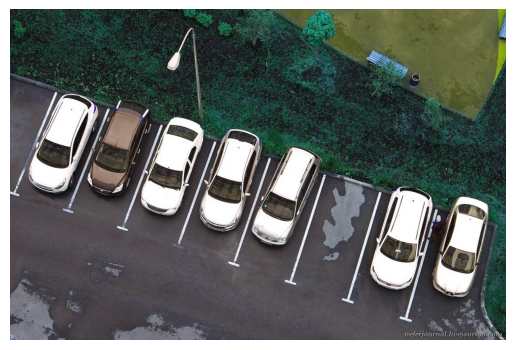

In [1395]:
# --- EASY
#(set_name, image_name) = ("easy", "29.png")           # the cartoonish one. 
#(set_name, image_name) = ("easy", "not_that_easy.jpg") # the fake cars ones with the concrete lines.
#(set_name, image_name) = ("easy", "easy.jpg")         # fake empty one with the bits of lines at the bottom
#(set_name, image_name) = ("easy", "20.png")           # The mirror one, real cars

# --- MEDIUM
#(set_name, image_name) = ("medium", "12.png")  # the one with the grass dividers on either side
#(set_name, image_name) = ("medium", "30.png")  # slightly askew lines
#(set_name, image_name) = ("medium", "31.png")  # top and bottom rows.

# --- HARD
#(set_name, image_name) = ("hard", "frame600.jpg") # dangan crop.
#(set_name, image_name) = ("hard", "frame1.jpg")   # dangan large.  Need to use the small scale flag.
(set_name, image_name) = ("hard", "21.png")       # the rotated image


image = images[set_name][image_name]
image = np.array(image)   
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
plt.imshow(image)
plt.axis('off')
plt.show()

In [1396]:
def mask_out_colour(img, color_hsv_deg=(206.7, 36.2, 68.2), h_tolerance=15, s_tolerance=15, v_tolerance=15, debug=False):
        # Unpack your HSV (0–360, 0–100, 0–100)
        H_deg, S_pct, V_pct = color_hsv_deg

        # Convert to OpenCV HSV ranges:
        # H: [0,179], S: [0,255], V: [0,255]
        H = int(H_deg / 2.0)
        S = int(S_pct * 2.55)
        V = int(V_pct * 2.55)

        # Convert tolerances from "deg / percentage" to OpenCV units
        h_tol_cv = int(h_tolerance / 2.0)
        s_tol_cv = int(s_tolerance * 2.55)
        v_tol_cv = int(v_tolerance * 2.55)

        lower = np.array([
            max(H - h_tol_cv, 0),
            max(S - s_tol_cv, 0),
            max(V - v_tol_cv, 0)
        ], dtype=np.uint8)

        upper = np.array([
            min(H + h_tol_cv, 179),
            min(S + s_tol_cv, 255),
            min(V + v_tol_cv, 255)
        ], dtype=np.uint8)

        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower, upper)

        if debug:
            print("Target HSV (OpenCV):", (H, S, V))
            print("Lower HSV bound    :", lower)
            print("Upper HSV bound    :", upper)
            print("Nonzero mask px    :", np.count_nonzero(mask))

        # Replace masked pixels with white in BGR
        masked_img = img.copy()
        masked_img[mask > 0] = (255, 255, 255)
        return masked_img, mask
                
        return masked_img, mask


nonzero: 5649
Masked area: 0.70%
Mask rejected (too large).


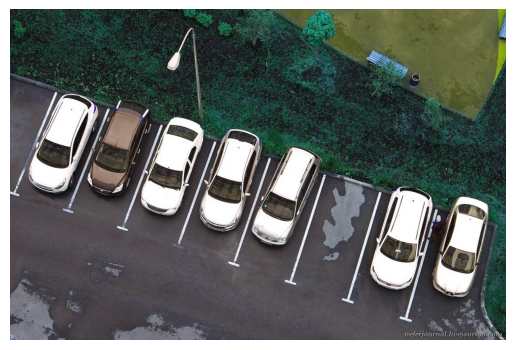

In [1397]:
def pre_mask(image):
    masked_img, mask = mask_out_colour(image)

    print("nonzero:", np.count_nonzero(mask))
    # Mask uses 255 for masked → convert to boolean
    mask_bool = mask > 0

    masked_pixels = np.sum(mask_bool)
    total_pixels  = mask_bool.size
    masked_ratio  = masked_pixels / total_pixels

    print(f"Masked area: {masked_ratio*100:.2f}%")
    
    return masked_img, masked_ratio

def apply_colour_correction_to_dangan(image, mask_threshold=0.0065):
    masked_img, masked_ratio = pre_mask(image)

    if masked_ratio <= mask_threshold:
        print("Mask accepted.")
        return masked_img
    else:
        print("Mask rejected (too large).")
        return image

masked_image = apply_colour_correction_to_dangan(image)
plt.imshow(masked_image)
plt.axis('off')
plt.show()

Full resolution edge density: 0.2453069577080491
Noisy — testing downsample attempt...
Downsampled edge density: 0.2110231923601637
Downsampled result is cleaner — using it.


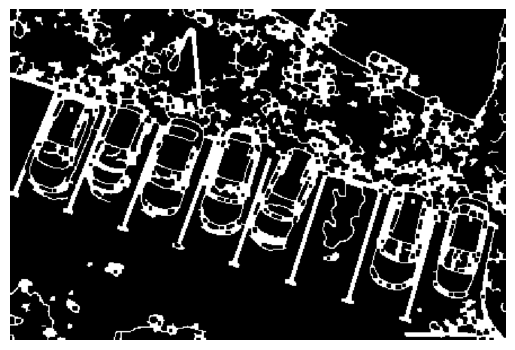

In [1398]:
def step_1(image):

    # --------------------------------------------
    # 1. Greyscale
    # --------------------------------------------
    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # --------------------------------------------
    # 2. Gaussian smoothing (true Canny blur)
    # --------------------------------------------
    grey_blur = cv2.GaussianBlur(grey, (3,3), 2)

    # --------------------------------------------
    # 3. Auto-Canny thresholds
    # --------------------------------------------
    med = np.median(grey_blur)
    sigma = 0.33
    low = int(max(0,  (1.0 - sigma) * med))
    high = int(min(255,(1.0 + sigma) * med))

    edges = cv2.Canny(grey_blur, low, high)

    # --------------------------------------------
    # 4. Morphological CLOSE to reconnect parking lines
    # --------------------------------------------
    close_kernel = np.ones((3,3), np.uint8)
    edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, close_kernel)

    return edges_closed


def edge_density(mask):
    """Compute white-pixel ratio in an edge mask."""
    total_pixels = mask.size
    white_pixels = np.count_nonzero(mask)
    return white_pixels / total_pixels


def smart_edges(image):

    # 1. First attempt (no downsample)
    edges = step_1(image)
    ratio_full = edge_density(edges)
    print("Full resolution edge density:", ratio_full)

    # If it's already fine → return it
    if ratio_full <= 0.09:
        return edges

    print("Noisy — testing downsample attempt...")

    # 2. Try downsampled version
    small = cv2.resize(image, (0,0), fx=0.4, fy=0.4)
    edges_small = step_1(small)

    # Upscale back for comparison
    edges_up = cv2.resize(edges_small, (image.shape[1], image.shape[0]),
                          interpolation=cv2.INTER_NEAREST)

    ratio_small = edge_density(edges_up)
    print("Downsampled edge density:", ratio_small)

    # --------------------------------------------
    # NEW LOGIC:
    # Only use downsampled result if it REDUCES noise
    # --------------------------------------------
    if ratio_small < ratio_full:
        print("Downsampled result is cleaner — using it.")
        return edges_up
    else:
        print("Downsampled result is noisier — keeping original.")
        return edges

edges = smart_edges(masked_image)
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

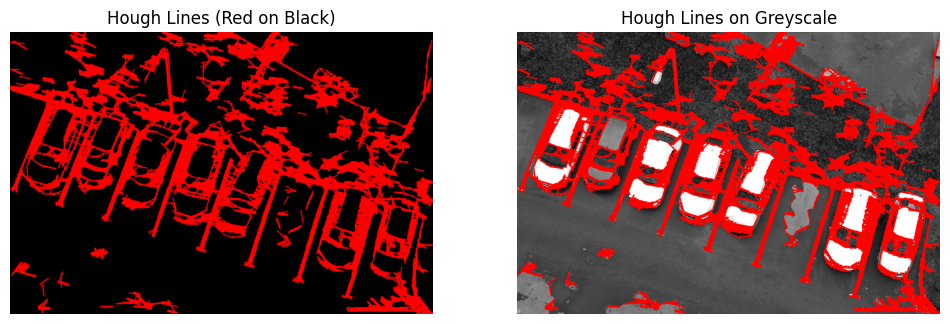

In [1399]:
def step_2_hough_lines(image, edges, percent_of_height=0.03):
    """
    image: original BGR image
    edges: edge mask from step_1 or smart_edges
    percent_of_height: fraction of the image height used for minLineLength
    """

    # --------------------------------------------
    # 1. Calculate size-dependent parameters
    # --------------------------------------------
    h, w = edges.shape[:2]

    min_line_length = int(h * percent_of_height)
    max_line_gap    = int(min_line_length / 2)

    # --------------------------------------------
    # 2. Hough Lines P
    # --------------------------------------------
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=50,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    # --------------------------------------------
    # 3. Output canvases
    # --------------------------------------------
    line_image_black = np.zeros((h, w, 3), dtype=np.uint8)

    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    grey_bgr = cv2.cvtColor(grey, cv2.COLOR_GRAY2BGR)

    # --------------------------------------------
    # 4. Draw lines
    # --------------------------------------------
    if lines is not None:
        for l in lines:
            x1, y1, x2, y2 = l[0]
            cv2.line(line_image_black, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.line(grey_bgr,        (x1, y1), (x2, y2), (0, 0, 255), 2)

    return line_image_black, grey_bgr, lines

black_lines, grey_with_lines, lines = step_2_hough_lines(masked_image, edges)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Hough Lines (Red on Black)")
plt.imshow(black_lines[..., ::-1])
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Hough Lines on Greyscale")
plt.imshow(grey_with_lines[..., ::-1])
plt.axis('off')

plt.show()


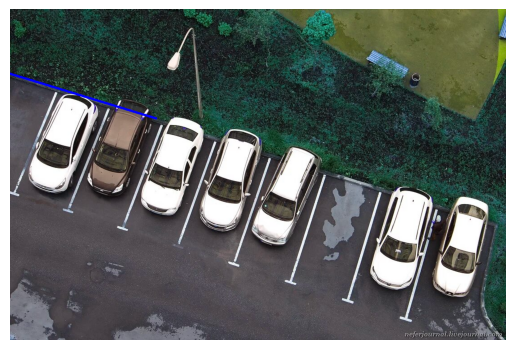

Dominant angle: 16.990823291986175


In [1400]:
def dominant_angle_from_longest_line(lines, image=None):
    """
    lines: output from cv2.HoughLinesP (Nx1x4)
    image: optional BGR image. If supplied, the longest line is drawn in red.

    Returns:
        angle_deg (float) or None
        debug_image (BGR) or None
    """

    if lines is None or len(lines) == 0:
        return None, None if image is not None else None

    longest_len = -1
    longest_line = None

    # --------------------------------------------
    # Find the longest Hough line
    # --------------------------------------------
    for l in lines:
        x1, y1, x2, y2 = l[0]
        length = np.hypot(x2 - x1, y2 - y1)

        if length > longest_len:
            longest_len = length
            longest_line = (x1, y1, x2, y2)

    if longest_line is None:
        return None, None if image is not None else None

    x1, y1, x2, y2 = longest_line

    # --------------------------------------------
    # Compute angle in degrees
    # Normalized to [-90, +90]
    # --------------------------------------------
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    angle = (angle + 90) % 180 - 90
    angle = float(angle)

    # --------------------------------------------
    # Optional: draw longest dominant line
    # --------------------------------------------
    debug_img = None
    if image is not None:
        debug_img = image.copy()
        cv2.line(debug_img, (x1, y1), (x2, y2), (0, 0, 255), 3)
        plt.imshow(debug_img)
        plt.axis('off')
        plt.show()
    
    return angle

angle = dominant_angle_from_longest_line(lines, image=masked_image)
print("Dominant angle:", angle)

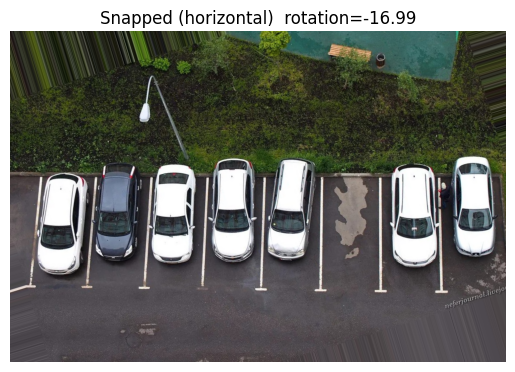

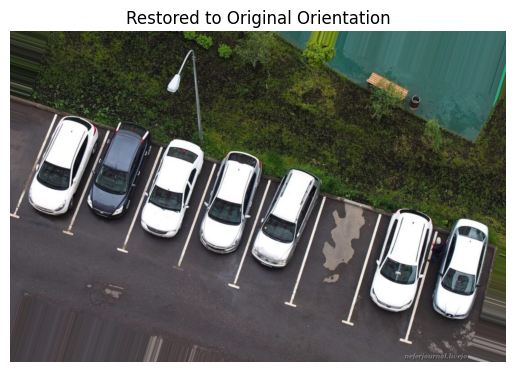

In [1401]:
def rotate_full(image, angle_deg):
    """
    Rotates the image by angle_deg WITHOUT cropping.
    Positive angle rotates CCW visually.
    """
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    # OpenCV rotates visually clockwise for positive angles,
    # so we negate to get normal CCW visuals.
    M = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    rotated = cv2.warpAffine(
        image, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )

    Minv = cv2.invertAffineTransform(M)

    return rotated, M, Minv



def snap_to_orientation(image, dominant_angle, threshold_deg=0):
    """
    Snaps image to 0° (horizontal) or 90° (vertical) WITHOUT cropping.
    Skips rotation if the required adjustment is below threshold_deg.
    """
    if dominant_angle is None:
        return image, 0, None, None, "none"

    # Determine target orientation
    if abs(dominant_angle) <= 45:
        target = 0
        snapped_to = "horizontal"
    else:
        target = 90 if dominant_angle > 0 else -90
        snapped_to = "vertical"

    rotation_needed = target - dominant_angle

    # ---- NEW: do nothing if rotation is tiny ----
    if abs(rotation_needed) < threshold_deg:
        return image, 0, None, None, "none (below threshold)"

    # Perform full rotation
    rotated, M, Minv = rotate_full(image, rotation_needed)

    return rotated, rotation_needed, M, Minv, snapped_to


def restore_original(rotated_image, Minv):
    """
    Uses the inverse rotation matrix to restore the original image.
    If Minv is None (meaning no rotation was applied), simply return the image.
    """
    if Minv is None:
        return rotated_image  # Nothing to undo

    h, w = rotated_image.shape[:2]

    restored = cv2.warpAffine(
        rotated_image, Minv, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )

    return restored
    
def rad2deg(radians):
    return radians * 180.0 / np.pi

snapped, rot_angle, M, Minv, orientation = snap_to_orientation(masked_image, angle)

plt.imshow(snapped[..., ::-1])
plt.title(f"Snapped ({orientation})  rotation={rot_angle:.2f}")
plt.axis('off')
plt.show()

restored = restore_original(snapped, Minv)

plt.imshow(restored[..., ::-1])
plt.title("Restored to Original Orientation")
plt.axis('off')
plt.show()

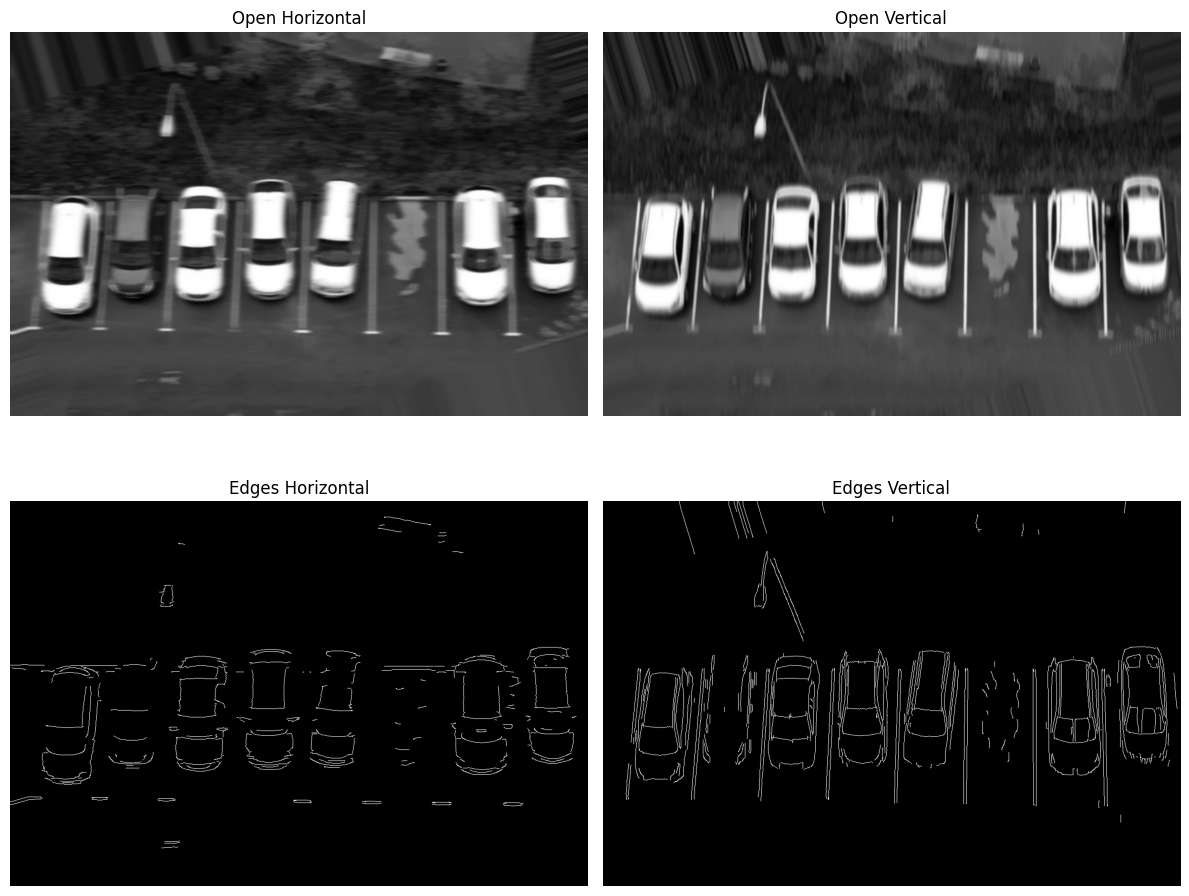

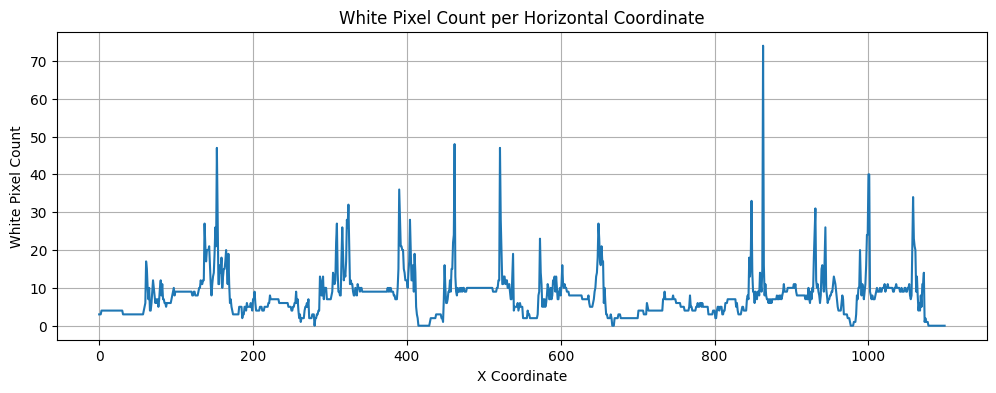

In [1402]:
def step_lines_rotated(image):
    """
    Strong directional line isolation after orientation snapping.
    Uses directional opening and anisotropic blurring.
    Automatically displays intermediate results.
    """

    # ------------------------------------------------------------
    # Greyscale + equalize
    # ------------------------------------------------------------
    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    grey_blur_v = cv2.GaussianBlur(grey, (3,21), 0)
    grey_blur_h = cv2.GaussianBlur(grey, (21,3), 0)

    # ------------------------------------------------------------
    # Directional structuring elements
    # ------------------------------------------------------------
    horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 1))
    vert_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 11))

    blur_h = cv2.GaussianBlur(grey_blur_h, (21, 3), 0)
    blur_v = cv2.GaussianBlur(grey_blur_v, (3, 21), 0)

    # ------------------------------------------------------------
    # Directional opening (remove noise not aligned to axes)
    # ------------------------------------------------------------
    open_h = cv2.morphologyEx(blur_h, cv2.MORPH_OPEN, horiz_kernel)
    open_v = cv2.morphologyEx(blur_v, cv2.MORPH_OPEN, vert_kernel)

    # ------------------------------------------------------------
    # Adaptive threshold to isolate strong lines
    # ------------------------------------------------------------

    # ------------------------------------------------------------
    # Final edges
    # ------------------------------------------------------------
    edges_h = cv2.Canny(open_h, 90, 120)
    edges_v = cv2.Canny(open_v, 90, 120)
    # ------------------------------------------------------------
    # Display results
    # ------------------------------------------------------------
    plt.figure(figsize=(12,10))

    plt.subplot(221)
    plt.imshow(open_h, cmap='gray')
    plt.title("Open Horizontal")
    plt.axis('off')

    plt.subplot(222)
    plt.imshow(open_v, cmap='gray')
    plt.title("Open Vertical")
    plt.axis('off')

    plt.subplot(223)
    plt.imshow(edges_h, cmap='gray')
    plt.title("Edges Horizontal")
    plt.axis('off')
    
    plt.subplot(224)
    plt.imshow(edges_v, cmap='gray')
    plt.title("Edges Vertical")
    plt.axis('off')


    plt.tight_layout()
    plt.show()

    return edges_h, edges_v, open_h, open_v

edges_h, edges_v, open_h, open_v = step_lines_rotated(snapped)

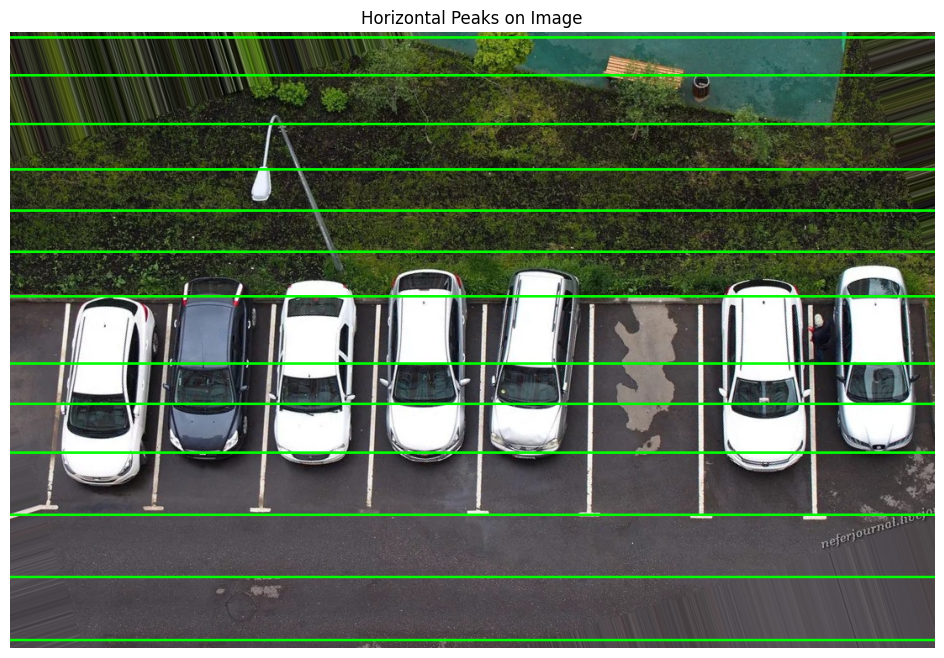

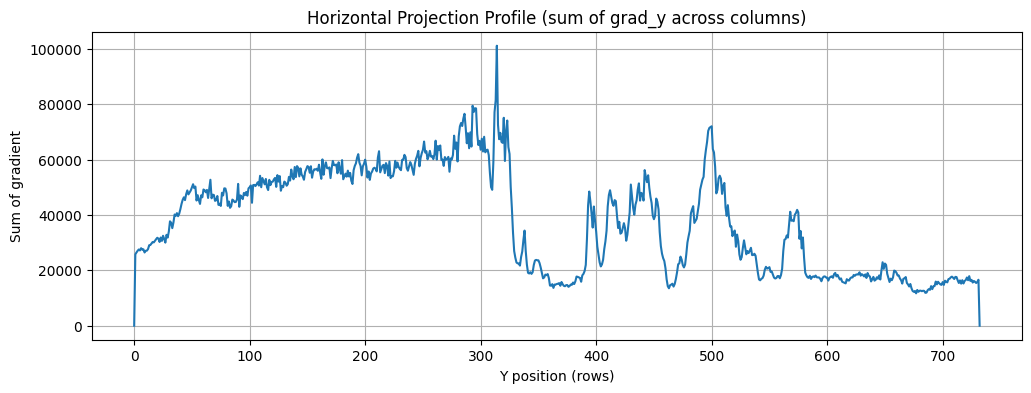

In [1403]:
# --- Convert to greyscale ---
grey = cv2.cvtColor(snapped, cv2.COLOR_BGR2GRAY)

# --- Horizontal gradient (dy=1) ---
grad_y = cv2.Sobel(grey, cv2.CV_16S, dx=0, dy=1, ksize=3)
grad_y = cv2.convertScaleAbs(grad_y)

# --- Horizontal projection: sum across columns ---
proj_h = np.sum(grad_y, axis=1)   # <-- axis=1 collapses columns → gives per-row sum

# --- Find horizontal peaks ---
h_peak_indices, _ = find_peaks(proj_h, distance=45)

# --- Draw horizontal peak lines ---
img_horiz = snapped.copy()

for y in h_peak_indices:
    cv2.line(
        img_horiz,
        (0, int(y)),
        (img_horiz.shape[1], int(y)),
        (0, 255, 0),
        2
    )

# --- Display results ---
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img_horiz, cv2.COLOR_BGR2RGB))
plt.title("Horizontal Peaks on Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(proj_h)
plt.title("Horizontal Projection Profile (sum of grad_y across columns)")
plt.xlabel("Y position (rows)")
plt.ylabel("Sum of gradient")
plt.grid(True)
plt.show()


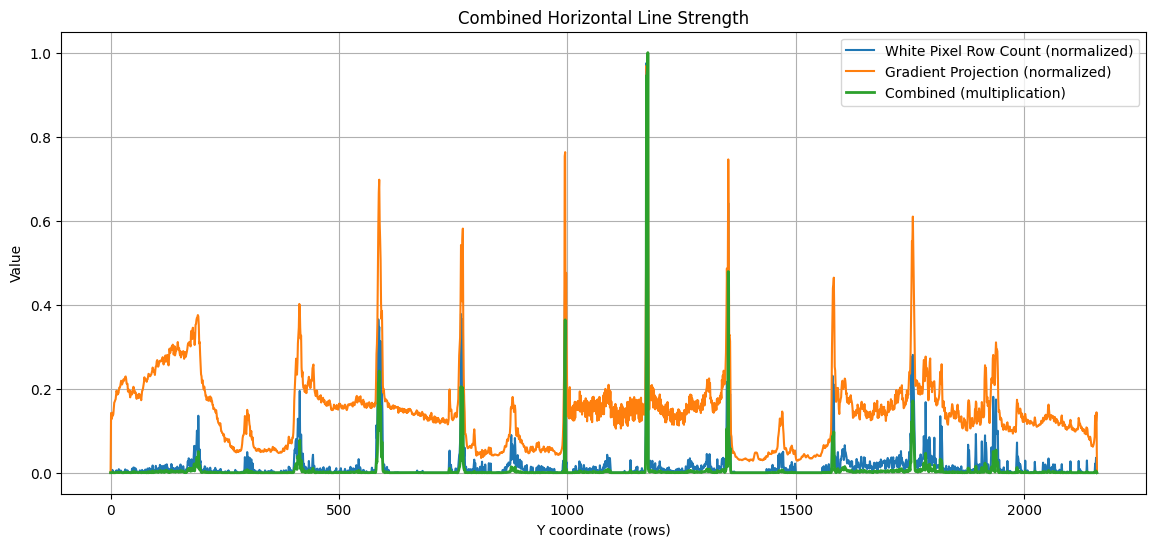

In [1394]:
# --- 1. Count white pixels per row from horizontal edges ---
binary_h = (edges_h > 0).astype(np.uint8)
white_counts_rows = binary_h.sum(axis=1)   # <-- per Y row

# --- 2. proj_h is already per-row (Y direction) ---
# proj_h = np.sum(grad_y, axis=1)

# --- 3. Normalize both (optional but recommended) ---
wc_norm = white_counts_rows / white_counts_rows.max()
proj_norm = proj_h / proj_h.max()

# --- 4. Multiply row-wise ---
combined_profile = wc_norm * proj_norm

# --- 5. Plot all three for comparison ---
plt.figure(figsize=(14,6))

plt.plot(wc_norm, label="White Pixel Row Count (normalized)")
plt.plot(proj_norm, label="Gradient Projection (normalized)")
plt.plot(combined_profile, label="Combined (multiplication)", linewidth=2)

plt.title("Combined Horizontal Line Strength")
plt.xlabel("Y coordinate (rows)")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()
